<a href="https://colab.research.google.com/github/Jxhyxxk/Python_jxhyxxk/blob/main/%EC%98%81%EC%83%81%EC%B2%98%EB%A6%AC_%EA%B8%B0%EB%A7%90_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **개념 정리**

Image Pyramid

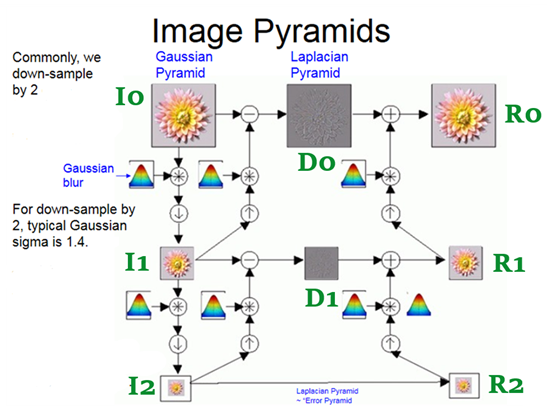

In [ ]:
'''
I0: 원본 이미지
I1: 가우샨 필터링 + 다운 샘플링된 I0
I2: 가우샨 필터링 + 다운 샘플링된 I1

D0: I0 - (Upsample)I1
D1: I1 - (Upsample)I2

R1: D1 + (Upsample)R2
R2: I2
R0: D0 + (Upsample)R1

 ● 위 연산을 통해서 Rn을 만드는 이유
   - 원본 이미지에 고주파 영역의 이미지(디테일)을 더해서, 원본의 선명도를 높임
   - In을 만들면서 다운샘플링을 진행하는데 이 과정에서 잡음이 제거됨


 ● 잡음 제거 과정
   - I계열이 고주파 노이즈가 제거된 이미지
   - 가우샨 블러를 통과하면서 고주파 영역이 제거되기 때문

 ● 선명화 과정
   - R 계열이 선명화 이미지
   - D계열이 원본에서 고주파가 제거된 I계열 이미지의 차이이기 때문에


'''

푸리에 변환

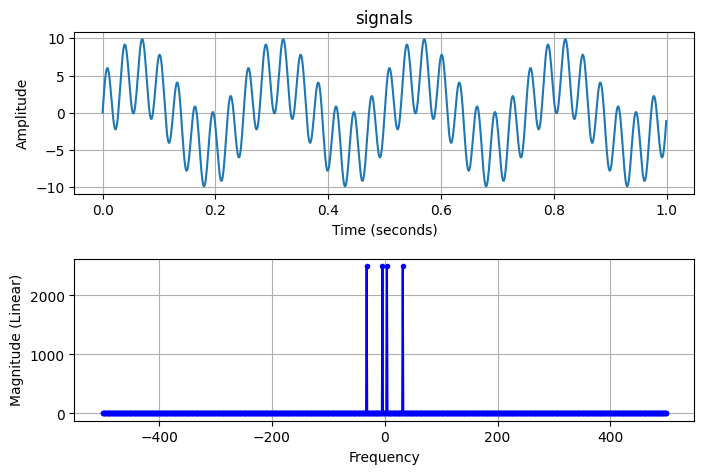

In [ ]:
# -*- coding: cp949 -*-

import numpy as np
from numpy.fft import fft, fftshift
import matplotlib.pylab as plt

Fs = 1000.    # the sampling frequency, 초당 1000회.
Ts = 1. / Fs  # the sampling period, 한 샘플 간격: 0.0001초

N = 1000  # 샘플 개수, 1000개의 데이터를 만든다.
freqStep = Fs / N  # 주파수 해상도

t = np.arange(N) * Ts  # t의 값은 0.000부터 0.999까지

y = np.zeros(N, np.float32)

# 신호 만들기.
for i in range(0, N) :
    y[i] = 5*np.sin(2*3.141592*4*i/N)+5*np.sin(2*3.141592*32*i/N)
         # y = 5sin(2π*4*i/N) + 5sin(2π*4*i/N)
         # y = [크기]sin(2π*f[주파수]*i/N) +  [크기]sin(2π*f*i/N)
Y = fft(y)  # FFT 변환
Y = fftshift(Y)  # 변환결과는 양쪽 끝에 있으나 해석하기 좋게 가운데로 위치 이동

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


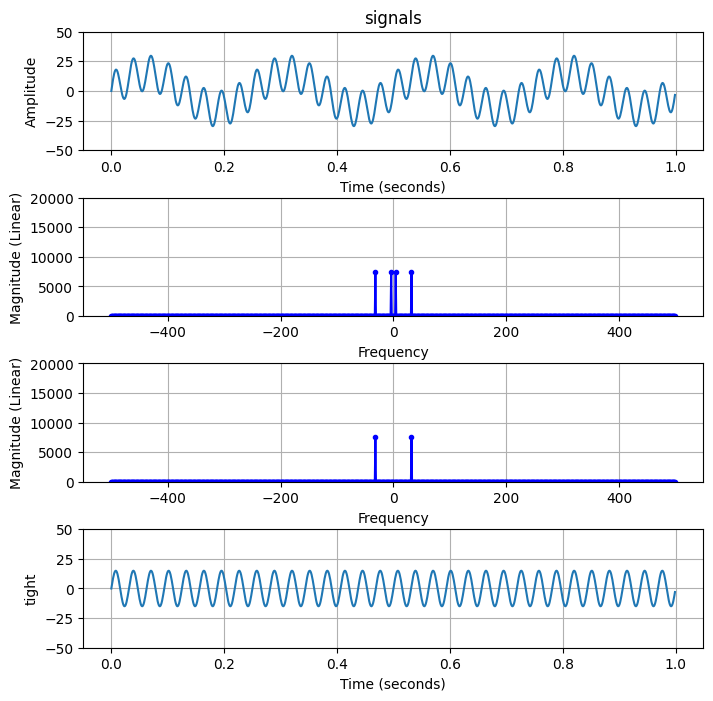

In [ ]:
from numpy.fft import fft, fftshift, ifft
import numpy as np
import matplotlib.pylab as plt

Fs = 1000. # 샘플링 주파수: 1초동안 Fs번 데이터를 찍을 것이다
Ts = 1. / Fs # 샘플링 주기: 연속 신호를 1/Fs초 마다 하나씩 샘플링할것이다 = 점의 간격
N = 1000 # 샘플 갯수: 전체 신호의 갯수
freqStep = Fs / N # resolution of the frequency in frequency domain
t = np.arange(N) * Ts # x ticks in time domain, t = n*Ts
y = np.zeros(N, np.float32)

# 4Hz, 32Hz 2개 각각 크기 15, 15인 신호의 합으로 신호를 만든다.
for i in range(0, N) :
 y[i] = 15*np.sin(2*3.141592*4*i/N)+15*np.sin(2*3.141592*32*i/N)

Y = fft(y) # FFT 변환
X = Y
Y = fftshift(Y) # middles the zero-point's axis

for i in range(0, 6) :  # 0~5 Hz 신호를 없앤다
 X[i] = 0.
for i in range(N-6, N) :  # 반대편 0~5 Hz 신호도 없앤다
 X[i] = 0.

x = ifft(X, None, -1, None) # 없애고 남은 주파수 부분을 역퓨리에 변환
X = fftshift(X)

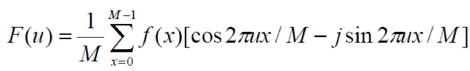

In [ ]:
'''
 ● 위 식이 푸리에 변환 하는 식으로 M은 f(x)의 개수(즉, 푸리에 변환 대상 데이터의 개수) 이고 u는 주파수를 나타냄.
'''

EX)

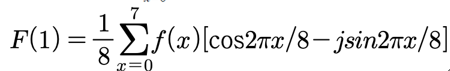

f(x)가 1일때 F(1)

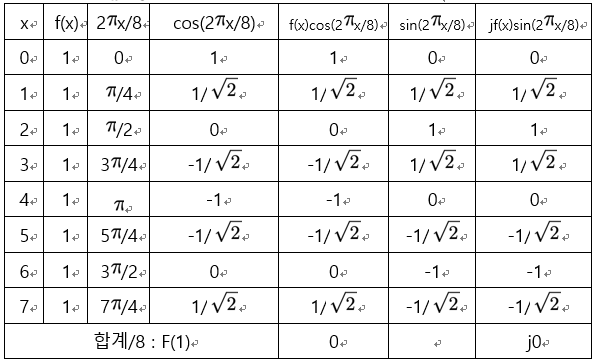

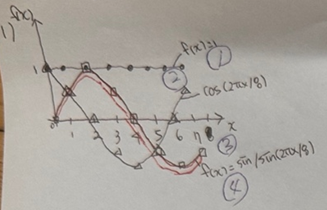

f(x)가 sin파 일때 F(1)

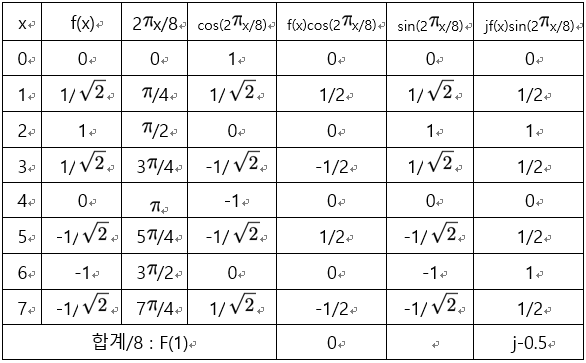

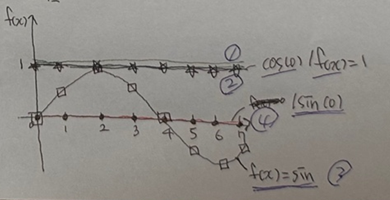

2차 푸리에 변환 식

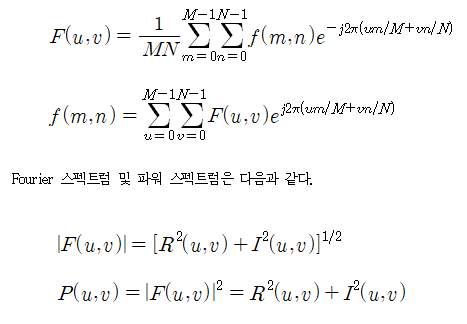

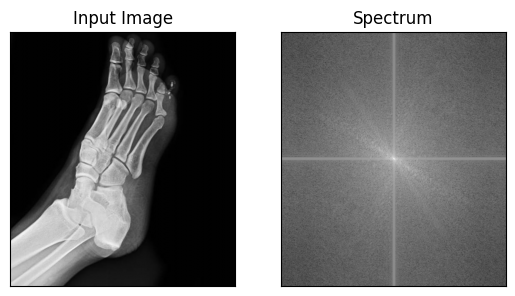

In [ ]:
# -*- coding: cp949 -*-
from pylab import *
from numpy.fft import fftshift, fft2
import cv2
import numpy as np

# 이미지 불러오기 & 생성
image = cv2.imread("foot.bmp", cv2.IMREAD_GRAYSCALE)
img = np.float32(image) # 사진을 실수형 배열로 변환

# 2차 푸리에 변환
f = fft2(img)
fshift = fftshift(f)

#스펙트럼
magnitude_spectrum = 20*np.log(np.abs(fshift)) #spectrum 구하는 수학식.


'''
DC(저주파) 크기(가운데 밝기): 전체 영상 평균 명암, 큰 덩어리 밝기 변화

수직·수평 선(중저주파 에지): 영상에 수평/수직 에지가 강하게 많다는 것

원형 점무늬(조금 더 고주파 질감): 뼈 조직·연조직 내부의 랜덤 질감 또는 미세 노이즈 정보

가장자리(극고주파 영역 어두움): 픽셀 단위 초미세 잡음은 적고, 에너지(진폭)가 거의 없다는 것
'''

교재 (2차 푸리에변환) 해석

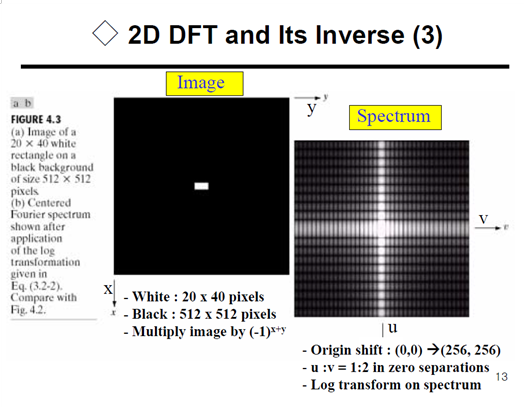

In [ ]:
'''
 ● 왼쪽에 있는 이미지를 스펙트럼으로 나타냈을 때를 알려주는 그림임
   - Image: 512X512 검은색 배경 위에 20X40 크기의 흰색 직사각형이 놓여있는 그림
   - Spectrum: Image를 푸리에 스펙트럼으로 나타낸 그림

 ● 스펙트럼 해석
   - 스펙트럼의 가운데 부분(u,v = 0,0): 저주파(DC성분), 좌표로는 u(수직)와 v(수평)로 나타냄
   - 직사각형의 테두리(위, 아래, 왼, 오른)가 만들어내는 신호를 스펙트럼으로 나타낸 것
   - 직사각형은 가로와 세로로 주로 이루어져있기 때문에 수평, 수직 부분이 강하게 스펙트럼으로 나타남
   - 가운데 부분 주위로 밝은 부분은 직사각형의 꼭지점에서의 변화(수직->수평 or 수평->수직 / 고주파)로 인해 나타남
   - Image에는 급격하게 변화하는 부분이 많지 않기 때문에 |u|, |v|의 값이 크지 않아 검은색으로 나타남
'''


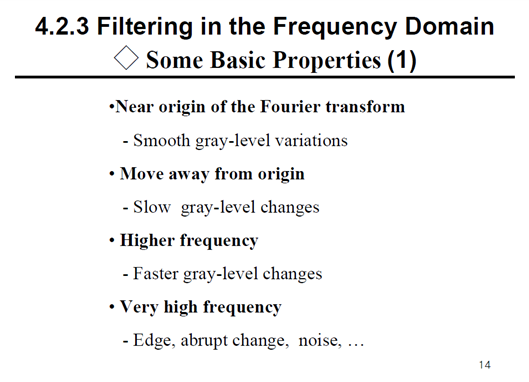

In [ ]:
'''
 ● Near origin of the Fourier transform
   – Smooth gray‐level variations
   - 스펙트럼의 가운데(0Hz 근처)는 영상에서 부드럽고 천천히 변하는 픽셀 값 정보
   - "넓은 검은 배경에서 흰색 직사각형으로 넘어가는 그라데이션”같이, 픽셀이 서서히 변하는 부분들은 저주파

 ● Move away from origin
   - Slow gray‐level changes
   - 중심에서 어느 정도 떨어진 위치(약중주파 영역)는“그레이 레벨(픽셀 값)이 중간 속도로 변하는 부분”에 해당
   - "큰 물체 경계”나 “넓은 면” 같은 중간 크기 변화

 ● Higher frequency
   - Faster gray‐level changes
   - 스펙트럼에서 더 멀리(중고주파) 떨어진 곳일수록 “픽셀 값이 빠르게 변화하는 부분”을 나타냄
   - 작은 물체의 테두리 경계나 가장자리에서 밝기가 순간적으로 바뀌는 부분

 ● Very high frequency
   - Edge, abrupt change, noise …
   - 스펙트럼의 가장자리(극고주파)에 가까우면 픽셀 값이 불연속적으로 급격히 바뀌는(에지), 턱 없이 짧은 변화(노이즈), 잡음같은 성분
   - 순간적으로 흰→검은 혹은 검은→흰 식으로 전환되는 잡음 같은 작은 디테일

'''

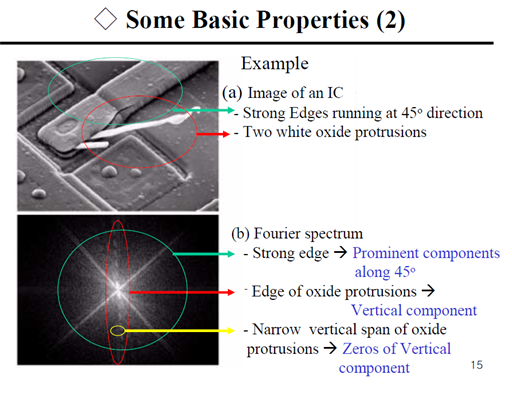

In [ ]:
'''
 a) IC 이미지
   - 강한 45°방향 에지 (녹색 원)
   - 사진 상단 왼쪽에 날카롭게 빗금친 채 결이 이어진 패턴이 보입니다. 이 부분이 45°방향으로 기울어진 선형 패턴(에지)
   - 두 개의 흰색 산화물 돌출부 (빨간 원)
   - 사진 오른쪽 중간쯤에 작은 흰색 둥근 모양(oxide protrusion)이 두 개 배치되어 있다
   - 가로로 좁고 긴 물체 위에 두 개의 원형 ‘산화물 덩어리’가 얹혀 있는 모습

 b) 스펙트럼 이미지
   - Strong edge: 원본 이미지에서 45°방향으로 이어진 에지가 강하다 / -45°방향도 마찬가지
   - Edge of oxide protrusions: 수직 방향의

   잘모르겠다 띠볼
'''

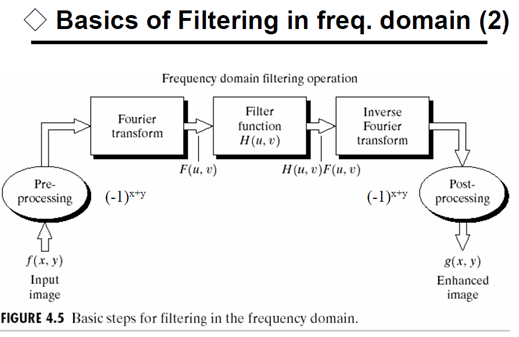

In [ ]:
'''
이 블록 다이어그램은 “주파수 영역에서 필터링을 수행할 때의 전체 흐름”을 보여줌

                                   𝑥+𝑦
1. Pre‐processing: Multiply by (−1)

                         𝑥+𝑦
입력 이미지 𝑓(𝑥,𝑦)를 (−1)    로 곱합니다.

목적: 2D DFT를 수행했을 때 ‘저주파(DC)’를 배열의 중앙으로 옮겨 주기 위한 사전 처리입니다.

                          𝑥+𝑦
즉, “𝑓′(𝑥,𝑦)=𝑓(𝑥,𝑦)⋅(−1)     ” 를 하면, DFT를 수행할 때 자동으로 ‘(0,0) 주파수’가 중앙에 위치하게 되어,
“필터링”이나 “시각화”를 할 때 훨씬 직관적이 됩니다.



2. Fourier transform → 𝐹(𝑢,𝑣)

변환된 결과는 복소수 스펙트럼 𝐹(𝑢,𝑣)(크기와 위상 정보 포함)입니다.



3.Filter function 𝐻(𝑢,𝑣)

필터 설계: 우리가 “어떤 주파수만 남기고/어떤 주파수를 제거할 것인지”를 결정하여,
그에 대응하는 이산 주파수 필터 𝐻(𝑢,𝑣) (크기) 를 정의합니다.

예를 들어, Ideal Lowpass Filter라면

         1,𝐷(𝑢,𝑣)≤𝐷0
𝐻(𝑢,𝑣)={
         0,𝐷(𝑢,𝑣)>𝐷0

여기서 𝐷(𝑢,𝑣)는 (𝑢,𝑣)에서의 “0 주파수(중앙)까지의 거리”이고, 𝐷0 는 컷오프 반경(cutoff)입니다.



4. Frequency‐domain multiplication → 𝐻(𝑢,𝑣)𝐹(𝑢,𝑣)

필터 적용 단계: 원본 푸리에 스펙트럼 𝐹(𝑢,𝑣)에, 설계한 필터 𝐻(𝑢,𝑣)를 곱해서
“원하는 주파수 대역만 남기고(1인 곳), 나머지는 제거(0으로 만든다)” 등의 작업을 수행합니다.

결과는 𝐺(𝑢,𝑣)=𝐻(𝑢,𝑣) 𝐹(𝑢,𝑣)로, 필터링된 스펙트럼이 됩니다.



5. Inverse transform → 역변환

필터 적용된 주파수 스펙트럼 𝐺(𝑢,𝑣)에 대하여 2D 역 푸리에 변환(iDFT, 즉 ifft2)을 수행하면

공간(픽셀) 도메인으로 다시 돌아와서 “필터가 적용되어 변형된 영상 𝑔(𝑥,𝑦)”을 얻을 수 있습니다.


                                    𝑥+𝑦
6. Post‐processing: Multiply by (−1)



                    𝑥+𝑦                                       𝑥+𝑦
처음에 전처리로 (−1)    를 곱했으면, 역변환을 마친 후에도 (−1)    를 다시 곱해 주어야
“원래 공간적 배치(픽셀 위치)에 맞는 밝기·위상”을 얻을 수 있습니다.


결과적으로, 이 과정 전체를 거치면 “어떤 필터(H)를 설계하느냐에 따라 저주파만 남겨 부드럽게 만들거나,
고주파만 살려서 에지만 강조하거나, 특정 방향 주파수만 살리는 등 다양한 용도의 영상 처리가 가능”해집니다.
'''

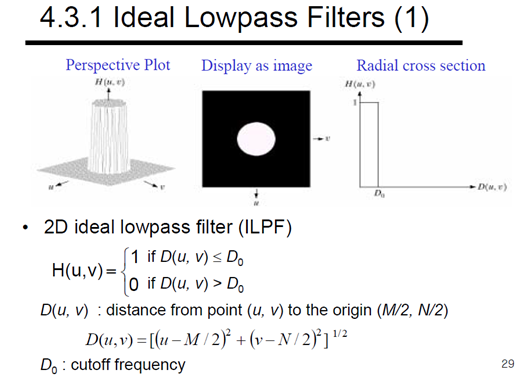

In [ ]:
'''
그림 해석

1. Perspective Plot (좌측 상단)

- 3차원 관점에서 본 ILPF의 형태입니다.(𝑢,𝑣)평면의 중앙을 기준으로
  𝐷0 이내 영역은 높이가 “1”인 평평한 원기둥(cylinder) 모양

- 𝐷0 반경을 벗어나면 높이가 “0”으로 곧바로 떨어지는 모양입니다.

- 즉, 원형 디스크 형태의 “1 값” 영역과 그를 둘러싼 “뒤쪽(고주파)에서는 0 값” 영역을 보여줌.


2. Display as Image (가운데 상단)

- 2D 흑백 이미지로 표현한 필터 𝐻(𝑢,𝑣)입니다.

- 중앙에 흰색 원(값=1)이 있고, 그 바깥쪽은 완전 검은색(값=0)으로 칠해져 있습니다.

- 흰색 원의 반경이 𝐷0를 나타냅니다.

- 실전에선 이 흰색 반지 안쪽 데이터만 남기고, 외부 데이터를 모두 검은색(=0)으로 만들어 줍니다.


3. Radial Cross Section (오른쪽 상단)

- (𝑢,𝑣)평면 상의 “반지름 방향(=distance from origin)”에 따른 𝐻(𝑢,𝑣)값을 나타낸 2D 그래프입니다.

- 𝑥축이 𝐷(𝑢,𝑣), 즉 중앙에서 떨어진 거리이고, 𝑦축이 𝐻(𝑢,𝑣) 값(0 또는 1)입니다.

- 중앙에서부터 𝐷=0에서 𝐷=𝐷0까지는 값이 1(높이 1)이고, 𝐷가 𝐷0를 초과하는 순간 갑자기 0으로 바뀌는 단계를 보여 줍니다.
'''

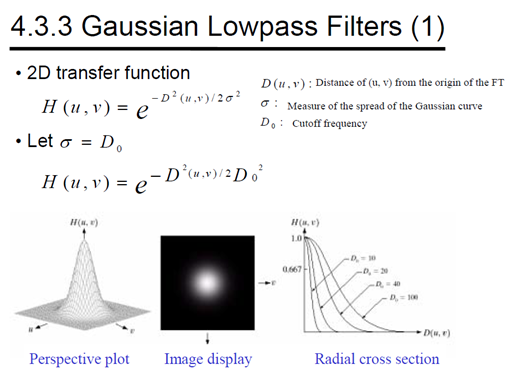

In [ ]:
'''
 ● 2D 가우샨 LPF
   - 영상 또는 신호의 고주파(급격한 변화, 노이즈)를 줄이고, 저주파(전체적인 윤곽, 부드러운 변화)만 남기는 필터


 ● 전달 함수

          2
        D  (u,v)
      - --------
             2
           2𝜎
 H(u,v)=e

 - 𝐻(𝑢,𝑣): 주파수 도메인에서 필터의 전달 함수 값 (u, v는 주파수 좌표)
 - D(u,v): 주파수 좌표 (𝑢,𝑣)가 원점(저주파 중심)으로부터 떨어진 거리
 - 𝜎: 가우시안 분포의 표준편차, 필터의 퍼짐 정도(널림 정도)
 - D0: 컷오프 주파수(cutoff frequency) — 보통 𝜎와 같은 의미로 사용

 ● 그림 설명
   - 첫 번째 그림은 가우샨 필터를 3D로 표현한것
   - 두 번째 그림은 가우샨 필터를 2D로 표현한 것
   - 세 번째 그림은 중심에서부터 한 방향으로 쭉 펼쳐서 필터 강도가 어떻게 약해지는지
   '''

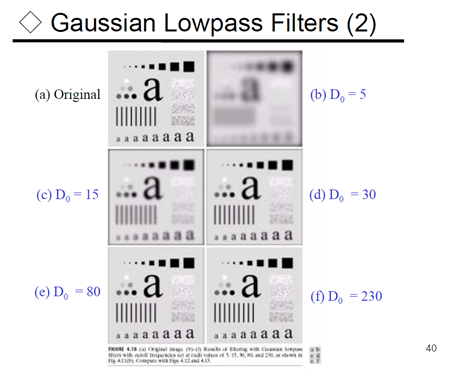

In [ ]:
'''
 - Cutoff 주파수 D0값에 따른 이미지의 변화를 보여준다
 - Cutoff 주파수 값이 작으면 이미지가 흐려지고 부드러운 효과를 주고
 - Cutoff 주파수 값이 크면 원본에 가깝고 선명해지는 효과를 준다
'''

**저주파 통과 및 고주파 통과 필터링**

저주파 통과 필터

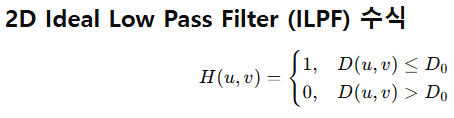

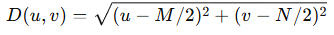

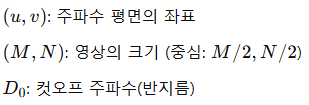

1.0540818


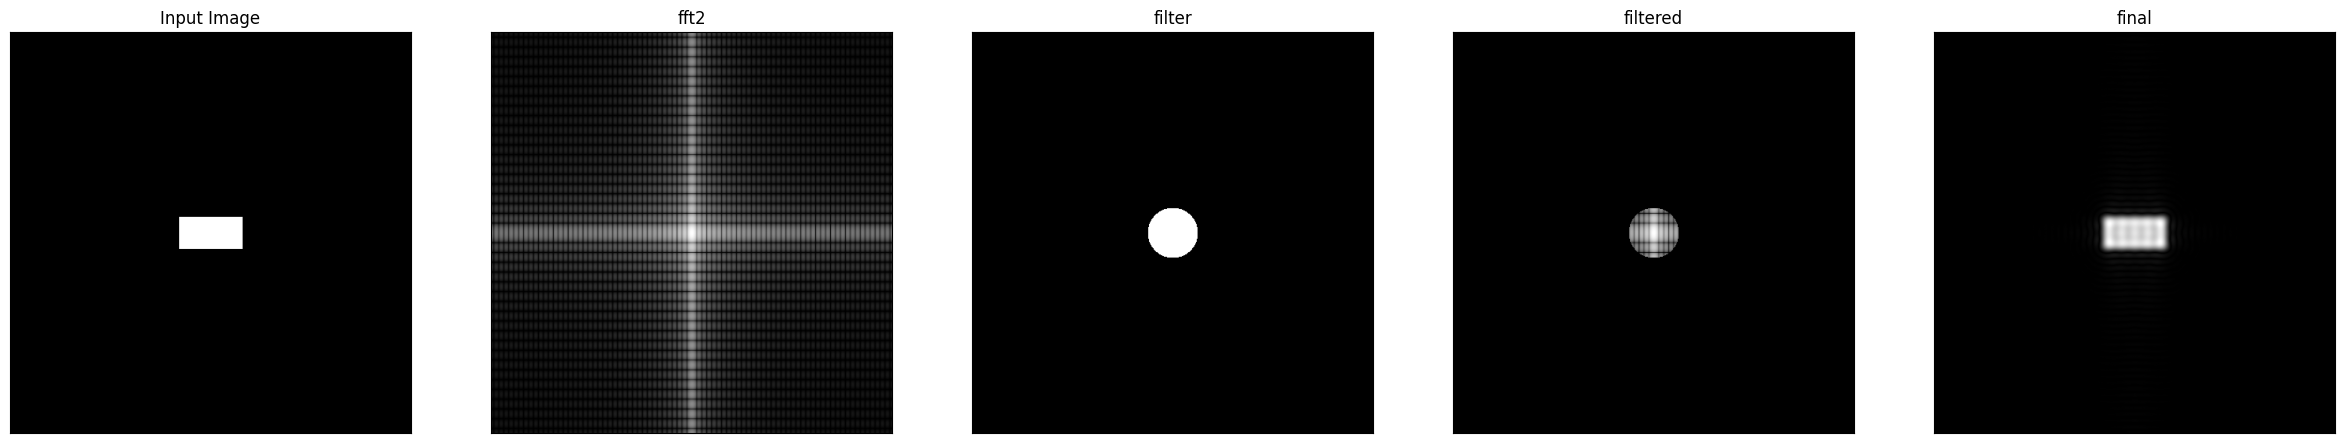

In [ ]:
# -*- coding: cp949 -*-
from pylab import *
from numpy.fft import *
import cv2
import numpy as np

# 이미지 만들기 (512X512 크기의 검은 바탕에서 중앙에 흰색 작은 사각형 생성)
image = np.zeros((512,512), np.float32)
image[236:277,216:297] = 1

# 2D 푸리에 변환
f_img = fft2(image) # 2D DFT (주파수 변환)
f = fftshift(f_img) # 중앙으로 0주파수 이동
fshift = f
magnitude_spectrum = 0.13*np.log(1+np.abs(fshift)) #스펙트럼 시각화 용 (log 스케일 변환)

# 필터 만들기 (전체를 차단하지만 중앙을 중심으로 반지름 32 안쪽만 통과함 -> 저주파는 통과, 고주파는 차단)
filter = np.zeros((512,512), np.float32)
for i in range(0, 512) :
   for j in range(0, 512):
    if np.sqrt((i-256)*(i-256) + (j-256)*(j-256)) < 32 :
      filter[i,j] = 1
    else:
      filter[i,j] = 0

# 필터 적용하기
filtered_img = f*filter
fimg_shift = ifftshift(filtered_img)
inverse_fimg = ifft2(fimg_shift)
inverse_fimg = np.abs(inverse_fimg)

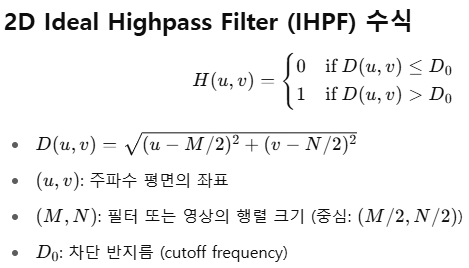

고주파 통과 필터

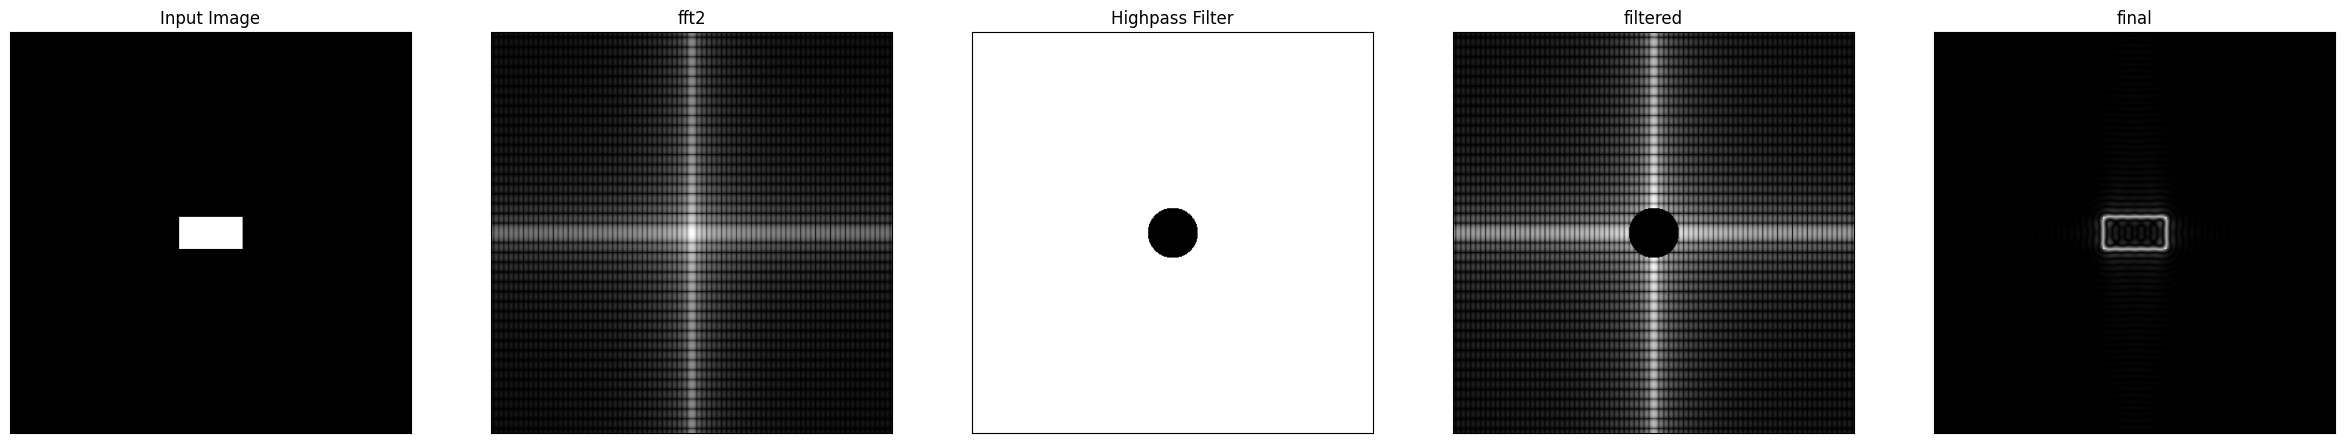

In [ ]:
# -*- coding: cp949 -*-
from pylab import *
from numpy.fft import *
import cv2
import numpy as np

# 이미지 만들기
image = np.zeros((512,512), np.float32)
image[236:277,216:297] = 1

f_img = fft2(image)
f = fftshift(f_img)
magnitude_spectrum = 0.13*np.log(1+np.abs(f))

# 고주파 통과 필터 만들기
filter = np.zeros((512,512), np.float32)
for i in range(0, 512) :
    for j in range(0, 512):
        # 반지름 32 이내는 0(저주파 차단), 바깥쪽은 1(고주파 통과)
        if np.sqrt((i-256)**2 + (j-256)**2) < 32 :
            filter[i,j] = 0
        else:
            filter[i,j] = 1

# 필터 적용하기
filtered_img = f * filter
fimg_shift = ifftshift(filtered_img)
inverse_fimg = ifft2(fimg_shift)
inverse_fimg = np.abs(inverse_fimg)

Morphological Transformations

**Open CV 모폴로지 연산**

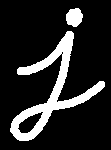 원본 이미지

In [ ]:
'''
 모폴로지 연산은 흑백 이미지(이진 이미지)에서 이미지의 구조나 형태를 분석, 수정하는 이미지 처리 기법
- 대표 목적
 1. 노이즈 제거
 2. 객체 확장, 축소
 3. 윤솩선 찾기, 구멍 메우기
'''

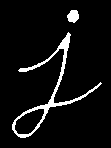 Erosion 이미지

In [ ]:
'''
 ● Erosion(침식)
  - 흰색(객체) 부분이 줄어들게 된다.
  - 커널이 중심 픽셀을 감쌀 때, 전체 커널 안에 모두 흰색이면 중심 픽셀을 흰색으로 남김
  - 하나라도 검정이면 검정으로 바꿈

  -효과: 얇은 노이즈, 잡음, 연결선 등 제거
         객체의 윤곽이 얇아짐
'''

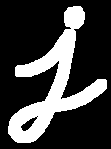 Dilation 이미지

In [ ]:
'''
 ● Dilation(팽창)
  - 흰색(객체) 부분이 커진다.
  - 커널이 중심 픽셀을 감쌀 때, 커널 내에 하나라도 흰색이 있으면 중심 픽셀을 흰색으로 바꿈

  - 효과: 객체가 두꺼워짐
          검정색(구멍, 노이즈) 메우기
'''

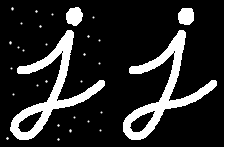 왼쪽이 입력 이미지, 오른쪽이 Opening 이미지

In [ ]:
'''
 ● Opening(열기)
   - 침식 후 팽창
   - 작은 노이즈 제거에 특히 효과적이다 (배경에 있는 작은 점들이 사라짐, 노이즈)

   - 효과: 작은 흰색 점(노이즈) 제거, 객체 크기 변화 적음
'''

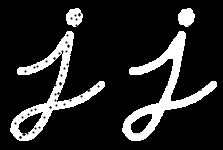 왼쪽이 입력이미지, 오른쪽이 Closing 이미지

In [ ]:
'''
 ● Closing(닫기)
  - 팽창 후 침식
  - 흰색 객체 안의 작은 검정 구멍을 메운다.

  - 효과: 객체 내부의 구멍(잡음, 어두운 점 등) 제거
'''

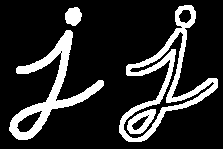왼쪽이 입력 영상, 오른쪽이 형태학적 Gradient 후 영상

In [ ]:
'''
 ● 형태학적 Gradient
   - 팽창 결과 - 침식 결과
   - 객체의 "윤곽선(외곽선)" 강조

   - 효과: 이미지의 경계선만 남기고 배경/객체의 내부는 제거
'''

구조 요소

In [ ]:
'''
 ● 구조요소: 형태학적 연산(모폴로지 연산)을 할 때 이미지의 커널 역할을 하는 행렬
   - 구조요소(커널)의 모양/크기에 따라 결과가 달라지게 된다.

 ● 종류
   - OpenCV: cv.getStructuringElement()을 이용하여서 만들 수 있다.

   - 직사각형 커널:  cv.getStructuringElement(cv.MORPH_RECT, (5,5))
     배열: ([[1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1]], dtype = uint8)


   - 타원형 커널: cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
     배열: ([[0, 0, 1, 0, 0],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1], dtype = uint8)


   - 십자형 커널: cv.getStructuringElement(cv.MORPH_CROSS, (5,5))
     배열: ([[0, 0, 1, 0, 0],
             [0, 0, 1, 0, 0],
             [1, 1, 1, 1, 1],
             [0, 0, 1, 0, 0],
             [0, 0, 1, 0, 0]], dtype = uint8)

'''

OpenCV: Image Transformation(영상변환/이미지의 기하학적 변형)

In [ ]:
'''
 ● 영상 변환: 이미지를 회전, 이동, 크기변경, 뒤집기 등 좌표의 변화를 이용해 이미지의 형태를 바꿈
'''

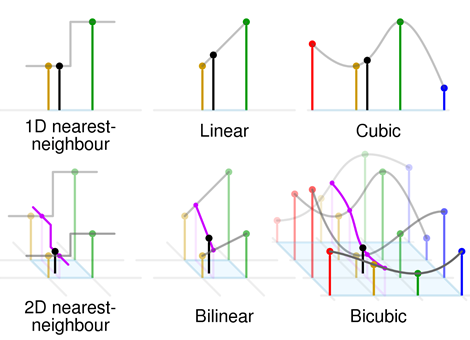

In [ ]:
'''
 위 사진들을 OpenCV에서 이미지 resize나 변환에서 사용하는 보간법으로 cv2.resize() 안에있는
interpolation 파라미터를 통해서 변경 가능하다.

 ● 1D Nearest-Neighbor (1차원 최근방 이웃 보간법) / cv2.INTER_NEAREST
  - 1D에서 주어진 값에 가장 가까운 값을 선택하는 방식이다.
  - 간단하지만, 부드럽지 않아 Step(계단형) 모양의 이미지 왜곡이 생길 수 있고 값이 불연속적으로 변화한다.
  - 그래프를 보면 x축을 따라 두 점을 연결했을 때, 값이 갑자기 변화하는 형태를 보인다.
  - 빠르지만, 고급스러운 결과를 원하지 않거나 계산을 빠르게 처리해야 할 때 사용한다.

 ● Linear (양선형 보간법) / cv2.INTER_LINEAR
  - 두 점 사이의 값을 직선으로 연결하여 보간한다. 두 점사이의 값을 linear(선형)으로 추정하는 방식
  - 비교적 부드럽고 예측 가능한 보간법으로 1D에서는 두 점사이를 직선으로 연결하고, 2D에서는 직선 평면을 이용한다.
  - 그래프를 보면 두 점을 직선으로 연결하는 방식을 보이고, 선형적인 변화가 있다.
  - 간단하지만, 보간이 부드러워 이미지를 비교적 잘 처리한다.

 ● Cubic (삼차 보간법) / cv2.INTER_CUBIC
  - 3차 다항식을 이용하여 두 점 사이의 값을 예측하는 방법으로, 4개의 점을 기준으로 한다.
  - Linear(선형 보간법)보다 훨씬 더 부드럽고 자연스러운 결과를 얻을 수 있다. 특히 곡선 형태의 변화를 잘 처리한다.
  - 그래프를 보면3차 다항식의 형태로 점들이 부드럽게 연결된다. 곡선 형태가 되어, 더 자연스러운 변화를 나타낸다.
  - 부드러운 결과를 원할 때 사용되고, 고품질 이미지를 처리할 때 유용하다.

 ● 2D Nearest-Neighbor (2차원 최근접 이웃 보간법) / cv2.INTER_NEAREST
  - 2D 이미지에서 각 픽셀에 대해 가장 가까운 이웃 픽셀을 선택하여 값을 할당하는 방법
  - 계산이 빠르지만 1D에서와 마찬가지로 부드럽지 않고 Step(계단)모양이 나올 수 있다.
  - 그래프를 보면 2D 평면에서 각 점을 연결하여 값이 급격하게 바뀌는 모습을 보인다.
  - 빠른 속도가 중요한 경우에 사용된다.

 ● Bilinear (이중 선형 보간법) / cv2.INTER_LINEAR
  - 2D 선형 보간법으로, 인접한 4개의 점을 기준으로 선형적으로 보간한다.
    수평과 수직 두 축을 기준으로 각각 선형 보간을 진행한다.
  - 부드럽고 자연스러운 결과를 얻을 수 있지만, 고급 보간법 보다는 부드럽지 않을 수 있다.
  - 그래프를 보면 2D의 4개의 점을 직선으로 연결하여, 더 부드럽게 값을 추정한다.
  - 비교적 부드럽고 빠른 게산을 원할 때 사용한다.

 ● Bicubic (이중 삼차 보간법) / cv2.INTER_CUBIC
  - 2D 삼차 보간법으로, 16개의 점을 기준으로 값을 에측한다.
    더 높은 차원의 다항식을 사용하여 2D에서 보간을 진행한다.
  - 매우 부드럽고 자연스러운 변화를 나타낸다
    이미지에서 고해상도의 디테일을 잘 살린다.
  - 16개의 점을 고려한 삼차 다항식을 사용하여 곡선 형태로 값을 추정한다.
  - 고해상도 이미지나 부드러운 변화를 원하는 경우 사용된다.




※ Nearest-Neighbor: 빠르고 간단하지만 부드럽지 않은 이미지 결과 / 빠른 처리 속도가 중요한 경우

   Linear: 두 점 사이의 선형 보간, 부드러운 결과 / 간단한 처리에서 사용

   Cubic: 3차 다항식을 사용하여 부드럽고 자연스러운 보간 / 이미지 품질을 중요하게 여길 때

   Bilinear: 2D에서 4개의 점을 기준으로 보간, 부드러운 결과 / 빠르면서도 부드러운 결과를 원하는 경우

   Bicubic: 2D에서 16개의 점을 기준으로 보간, 가장 부드럽고 자연스러운 결과 / 고품질, 세밀한 디테일이 중요한 경우
'''

1. Translation (이미지 이동)

(<Axes: >, <matplotlib.image.AxesImage at 0x7cc95c17ef90>)

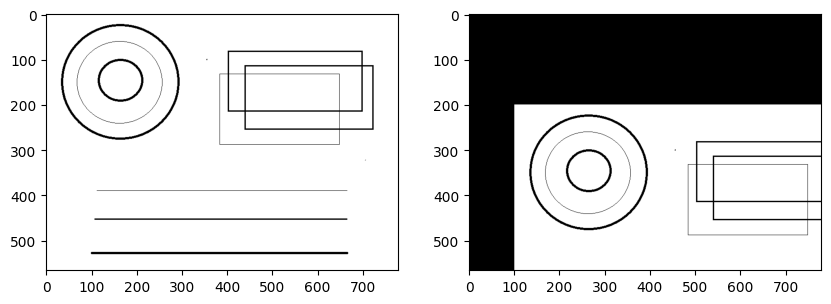

In [ ]:
# 변환 행렬, X축으로 100, Y축으로 200 이동
M = np.float32([[1,0,100],[0,1,200]])
dst = cv2.warpAffine(img, M,(cols, rows))

2. Rotation (이미지 회전)

[[  0.     0.5  248.  ]
 [ -0.5    0.   477.75]]


(<Axes: >, <matplotlib.image.AxesImage at 0x7cc95460bc50>)

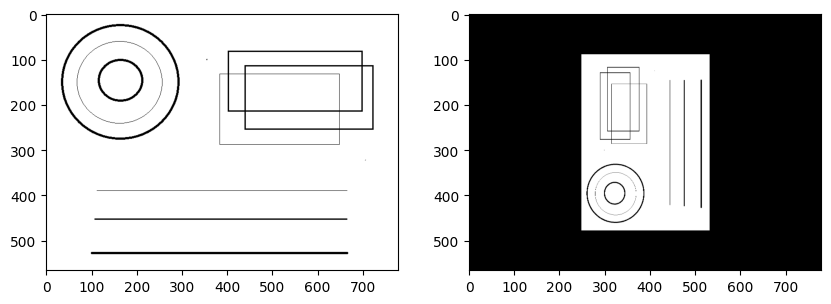

In [ ]:
# 이미지의 중심점을 기준으로 90도 회전 하면서 0.5배 Scale
M = cv2.getRotationMatrix2D((cols/2, rows/2), 90, 0.5)

dst = cv2.warpAffine(img, M,(cols, rows))

3. Affine Transformation(임의의 선형 변환)

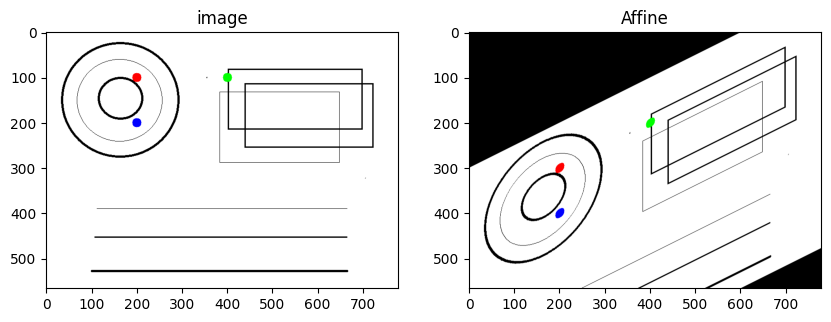

In [ ]:
pts1 = np.float32([[200,100],[400,100],[200,200]])  # 원본 이미지에서의 점 3개
pts2 = np.float32([[200,300],[400,200],[200,400]])  # 변환 후 위치의 점 3개

M = cv2.getAffineTransform(pts1, pts2)              # Affine 변환 행렬 계산
# 입력을 pst1과 pst2를 받아 어떤 Affine 행렬을 사용해야하는지를 구함

dst = cv2.warpAffine(img, M, (cols,rows))           # 실제 변환
# M을 통해서 구한 Affine 행렬을 실제로 적용시킴

In [ ]:
'''
 ● 직선성과 평행성을 보존하면서 이미지를 회전, 이동, 크기 변경, 기울임(비스듬하게 하기)까지 가능한 변환
   - 사각형이 사다리꼴로 바뀔 수 있지만 직선은 항상 직선으로 남고, 평행선은 계속 평행하게 유지됨
'''

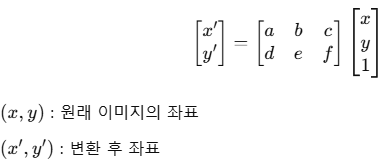

In [ ]:
'''
위와 같은 2X3 변환 행렬을 사용한다

 ● 3개의 점만 정하면, 그 점들이 새로운 위치에 가도록 변환 행렬을 계산한다.

'''

4. Perspective Transformation

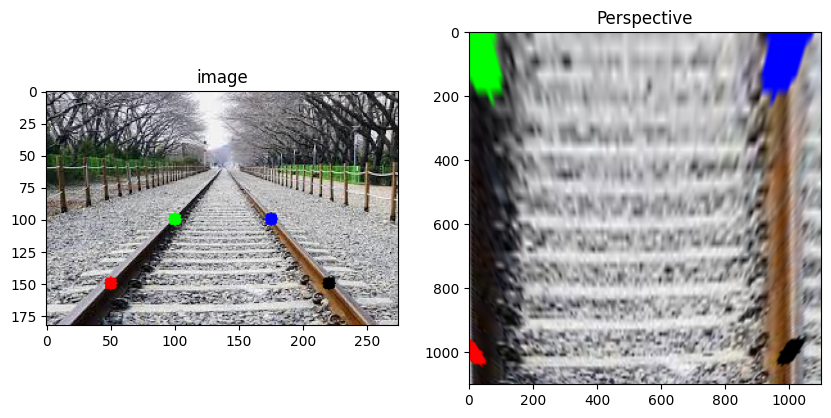

In [ ]:
#-*- coding:utf-8 -*-
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/perspective.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# [x,y] 좌표점을 4x2의 행렬로 작성
# 좌표점은 좌상->좌하->우상->우하
pts1 = np.float32([[100,100],[50,150],[175,100],[220,150]])

# 좌표의 이동점
pts2 = np.float32([[10,10],[10,1000],[1000,10],[1000,1000]])

# img_rgb에 pts1의 좌표점 표시 (4개 점)
cv2.circle(img_rgb, (50, 150), 5, (255, 0, 0), -1)  # 빨강
cv2.circle(img_rgb, (100, 100), 5, (0, 255, 0), -1)  # 초록
cv2.circle(img_rgb, (175, 100), 5, (0, 0, 255), -1)  # 파랑
cv2.circle(img_rgb, (220, 150), 5, (0, 0, 0), -1)    # 검정

# 투시 변환 행렬 계산 및 적용
M = cv2.getPerspectiveTransform(pts1, pts2)
dst = cv2.warpPerspective(img_rgb, M, (1100,1100))

# 결과 출력
plt.figure(figsize=(10,20))
plt.subplot(121), plt.imshow(img_rgb), plt.title('image')
plt.subplot(122), plt.imshow(dst), plt.title('Perspective')
plt.show()

In [ ]:
'''
 ● Perspective 변환
   - 이미지에서 직선이 왜곡되고, 평면에서의 왜곡을 3D처럼 보이게 하는 변환
   - 멀리 있는 물체는 작게 보이고 가까운 물체는 크게 보이는 원리
   - Affine과 다르게 4개의 점을 사용한다.
   - 직선성만 보존
   - 병행선은 보존되지 않음
'''

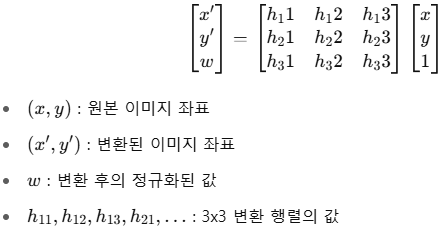

In [ ]:
'''
 Perspective는 위 3X3 변환 행렬을 사용한다.
'''

Image Restoration

원본

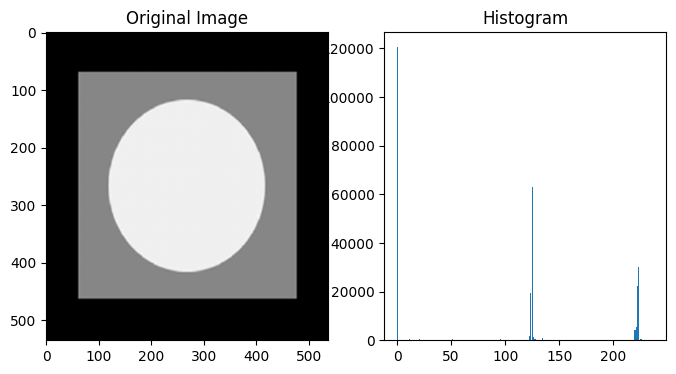

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/Fig0503(original_pattern).tif', 0)
m, n = img.shape[:2]

# 원본 이미지와 히스토그램 출력
f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img, cmap='gray', aspect='auto')
ax[0].set_title("Original Image")
ax[1].hist(img.flatten(), bins=256)
ax[1].set_title("Histogram")
plt.show()

Gaussian Noise

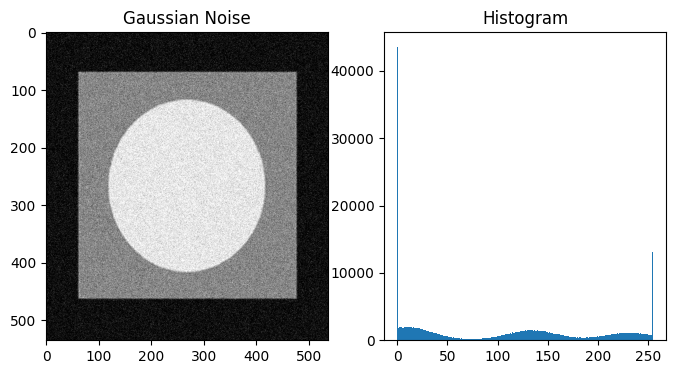

In [21]:
mean = 10
std = 25
noise = np.random.normal(mean, std, (m, n))
Gau_noisy_img = img + noise
Gau_noisy_img = np.clip(Gau_noisy_img, 0, 255).astype(np.uint8)

f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Gau_noisy_img, cmap='gray', aspect='auto')
ax[0].set_title('Gaussian Noise')
ax[1].hist(Gau_noisy_img.flatten(), bins=256)
ax[1].set_title('Histogram')
plt.show()

In [ ]:
'''
 ● Gaussian Noise
   noise = np.random.normal(mean, std, (m,n))
   Gau_noisy_img = img + noise

 ● 필터 설명
   평균 10, 표준편차, 25인 정규분포 노이즈를 더한 이미지이다.
   픽셀 값이 상하로 흔들림
'''

Rayleigh Noise

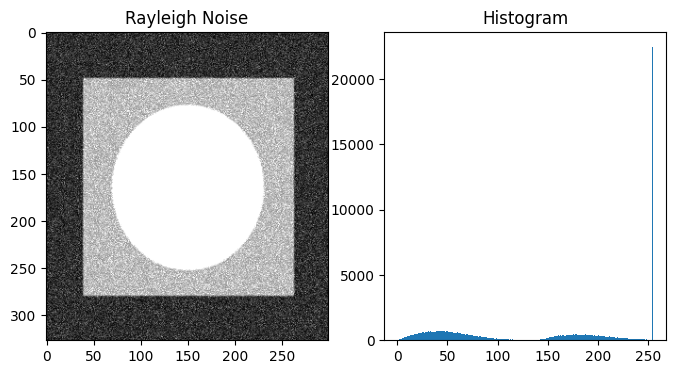

In [19]:
std = 40
noise = np.random.rayleigh(scale=std, size=(m, n))
Ray_noisy_img = img + noise
Ray_noisy_img = np.clip(Ray_noisy_img, 0, 255).astype(np.uint8)

f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Ray_noisy_img, cmap='gray', aspect='auto')
ax[0].set_title('Rayleigh Noise')
ax[1].hist(Ray_noisy_img.flatten(), bins=256)
ax[1].set_title('Histogram')
plt.show()

In [ ]:
'''
 ● Rayleigh Noise
   noise = np.random.rayleigh(scale=std, size=(m,n))
   Ray_noisy_img = img + noise

 ● 필터 설명
   Scale=40의 레이리 분포 노이즈
   주로 레이더, 초음파 등의 영상에서 나타나는 노이즈
   한쪽으로 치우친 분포를 보인다.
'''

Gamma Noise

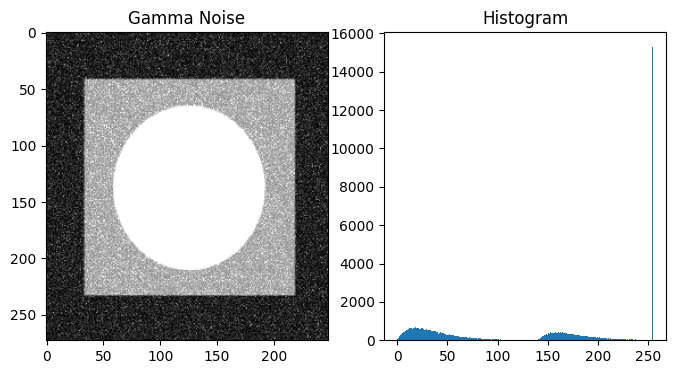

In [5]:
shape = 2.0
std = 18
noise = np.random.gamma(shape, std, (m, n))
Gam_noisy_img = img + noise
Gam_noisy_img = np.clip(Gam_noisy_img, 0, 255).astype(np.uint8)

f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Gam_noisy_img, cmap='gray', aspect='auto')
ax[0].set_title('Gamma Noise')
ax[1].hist(Gam_noisy_img.flatten(), bins=256)
ax[1].set_title('Histogram')
plt.show()

In [ ]:
'''
 ● Gamma Noise
   noise = np.random.gamma(shape, std, (m,n))
   Gam_noisy_img = img + noise

 ● 필터 설명
   감마 노이즈는 양(+)의 값만 존재
   저조도 환경의 노이즈 모델링에 적합
'''

Exponential Noise

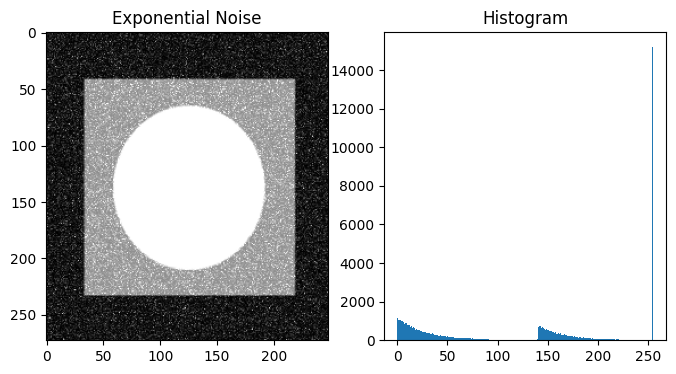

In [6]:
std = 26
noise = np.random.exponential(std, (m, n))
Exp_noisy_img = img + noise
Exp_noisy_img = np.clip(Exp_noisy_img, 0, 255).astype(np.uint8)

f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Exp_noisy_img, cmap='gray', aspect='auto')
ax[0].set_title('Exponential Noise')
ax[1].hist(Exp_noisy_img.flatten(), bins=256)
ax[1].set_title('Histogram')
plt.show()

In [ ]:
'''
 ● Exponential Noise
   noise = np.random.exponential(std,(m,n))

 ● 필터 설명
   sdt=26인 지수 분포 노이즈
   0 근처 값은 자주 나타나고, 큰 값은 드물게 나타남
   결과적으로 밝기가 증가
'''

Uniform Noise

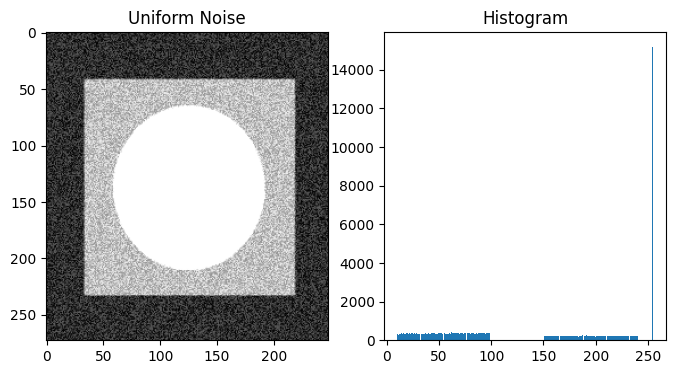

In [7]:
a, b = 10, 100
noise = np.random.uniform(a, b, (m, n))
Uni_noisy_img = img + noise
Uni_noisy_img = np.clip(Uni_noisy_img, 0, 255).astype(np.uint8)

f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Uni_noisy_img, cmap='gray', aspect='auto')
ax[0].set_title('Uniform Noise')
ax[1].hist(Uni_noisy_img.flatten(), bins=256)
ax[1].set_title('Histogram')
plt.show()

In [ ]:
'''
 ● Uniform Noise
   noise = np.random.uniform(a,b,(m,n))

 ● 필터 설명
   10~100 사이의 균등하게 랜덤 발생
   밝기의 변화가 무작위하면서 균등함
'''

Salt&Pepper Noise

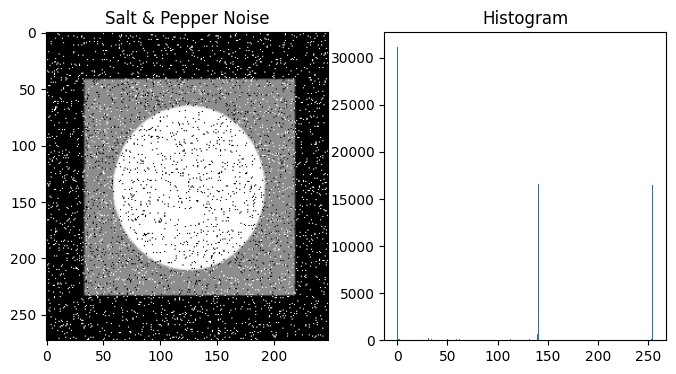

In [8]:
number_black = int(m * n * 0.05)
number_white = int(m * n * 0.05)

m_blacks = np.random.randint(0, m, number_black)
n_blacks = np.random.randint(0, n, number_black)
m_whites = np.random.randint(0, m, number_white)
n_whites = np.random.randint(0, n, number_white)

SP_noisy_img = np.copy(img)
SP_noisy_img[m_blacks, n_blacks] = 0
SP_noisy_img[m_whites, n_whites] = 255

f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(SP_noisy_img, cmap='gray', aspect='auto')
ax[0].set_title('Salt & Pepper Noise')
ax[1].hist(SP_noisy_img.flatten(), bins=256)
ax[1].set_title('Histogram')
plt.show()

In [ ]:
'''
 ● Salt&Pepper Noise
   number_black = int(m * n * 0.05)
   number_white = int(m * n * 0.05)

   m_blacks = np.random.randint(0, m, number_black)
   n_blacks = np.random.randint(0, n, number_black)
   m_whites = np.random.randint(0, m, number_white)
   n_whites = np.random.randint(0, n, number_white)

   SP_noisy_img = np.copy(img)
   SP_noisy_img[m_blacks, n_blacks] = 0
   SP_noisy_img[m_whites, n_whites] = 255

 ● 코드 설명
   전체 픽셀의 5%를 0(검은색), 5%를 255(흰색)로 설정
   이미지의 해당 픽셀들이 점 형태로 나타남
   전송 오류 등에서 자주 발생함
'''

Arithmetic Mean Filter

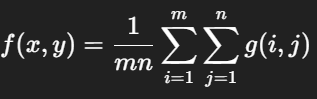

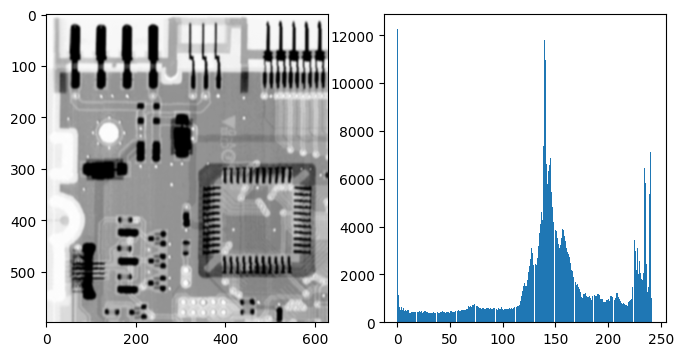

In [30]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

gaus_img = cv2.imread('/content/drive/MyDrive/Fig0507(b)(ckt-board-gauss-var-400).tif',0)
ksize = 5

# Arithmetic mean filter
arithmean = cv2.blur(gaus_img, (ksize,ksize))

In [ ]:
'''
 ● 코드 설명
  5X5 크기의 커널을 적용하고, 그 필터 내의 모든 픽셀 값의 산술 평균을 적용함

 ● 특징
  가장 간단하고 많이 쓰임
  가우샨 노이즈 제거에 효과적
  엣지나 세부 구조가 희려짐 → 블러효과
'''

Geometric Mean Filter

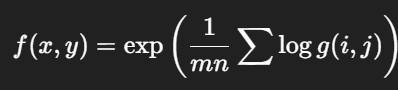

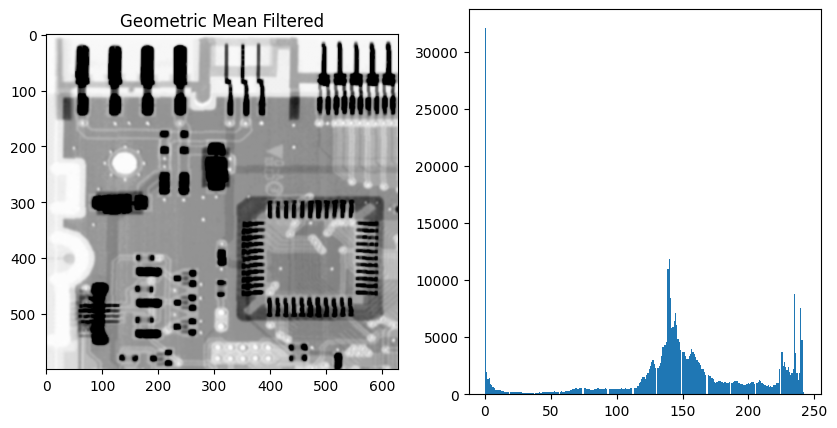

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def geometric_mean_filter(img, ksize=3):
    pad_size = ksize // 2
    padded = np.pad(img, pad_size, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+ksize, j:j+ksize].astype(np.float32) + 1e-5  # avoid log(0)
            log_region = np.log(region)
            mean_log = np.mean(log_region)
            geo_mean = np.exp(mean_log)
            output[i, j] = geo_mean

    return np.clip(output, 0, 255).astype(np.uint8)

In [ ]:
'''
 ● 코드 설명
   5X5 크기의 커널을 적용하고, 커널은 모든 픽셀 값의 기하 평균을 계산함

 ● 특징
   곱셈 기반 필터이기 때문에 극단적인 값(노이즈)의 영향이 적음
   에지 보존력이 좋음
   양수 픽셀만 처리 가능 → log를 사용하기 때문에 0이나 음수값은 계산 X
   Salt&Pepper 노이즈엔 효과가 적음
'''

Harmonic Mean Filter

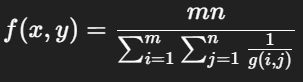

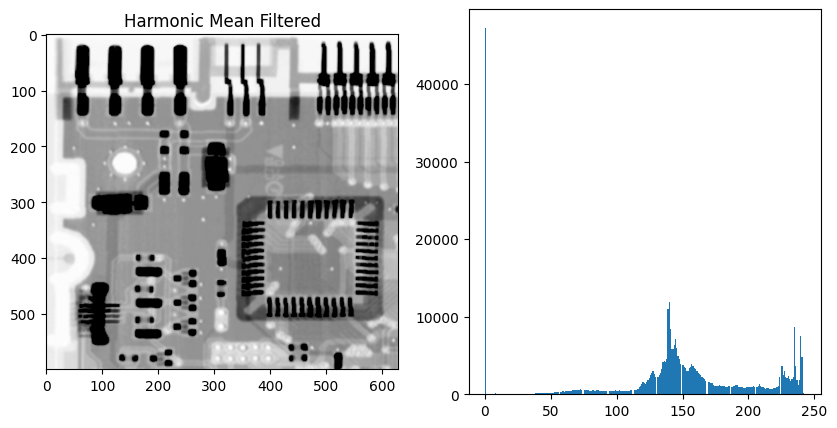

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def harmonic_mean_filter(img, ksize=3):
    pad_size = ksize // 2
    padded = np.pad(img, pad_size, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)

    eps = 1e-5  # divide-by-zero 방지

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+ksize, j:j+ksize].astype(np.float32) + eps
            hmean = (ksize * ksize) / np.sum(1.0 / region)
            output[i, j] = hmean

    return np.clip(output, 0, 255).astype(np.uint8)

In [ ]:
'''
 ● 코드
   5X5 크기의 커널을 적용하고 커널은 픽셀 값들의 조화 평균을 사용함

 ● 특징
   Salt noise(백색 노이즈) 제거에 효과적임
   픽셀 값이 크면 영향이 적어짐 → 검은색 픽셀에서의 영향이 적음
   0 근처의 값이 포함되면 불안정해짐
'''

# **족보풀이**

2024년 기말

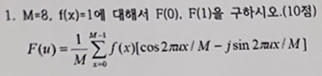

In [ ]:
'''
M=8, f(x)=1 일때 F(0)과 F(1)의 값을 구하는 문제이므로

F(0)부터 구해보면 아래와 같은 식이 나온다
'''

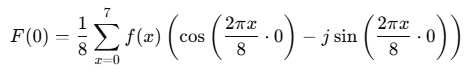

In [ ]:
'''
위 식을 계산해보면 F(0)=1 이라는 값이 나오게 된다.

그 후, F(1)을 구해보면
'''

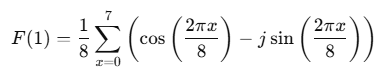

In [ ]:
'''
위와 같은 식이 나오게 되고 이를 표를 통해서 계산해 보면, 아래 그림과 같다.
'''

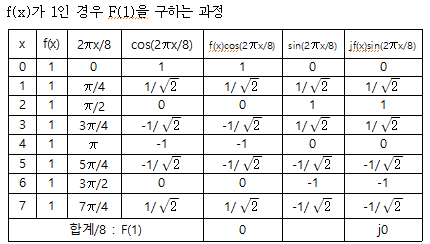

In [ ]:
import numpy as np

M = 8
f_x = [1, 1, 1, 1, 1, 1, 1, 1]
F1_real = 0
F1_imag = 0

for x in range(M):
    angle = (2 * np.pi * x) / M
    cos_val = np.cos(angle)
    sin_val = np.sin(angle)

    F1_real += f_x[x] * cos_val
    F1_imag -= f_x[x] * sin_val

F1_real /= M
F1_imag /= M

F1 = complex(F1_real, F1_imag)
print("F(1):", F1)


F(1): (-6.938893903907228e-17+2.7755575615628914e-17j)


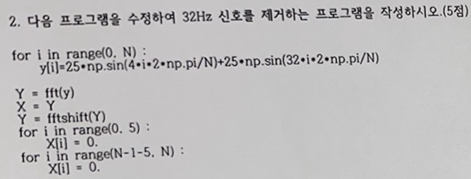

(1000,) complex64


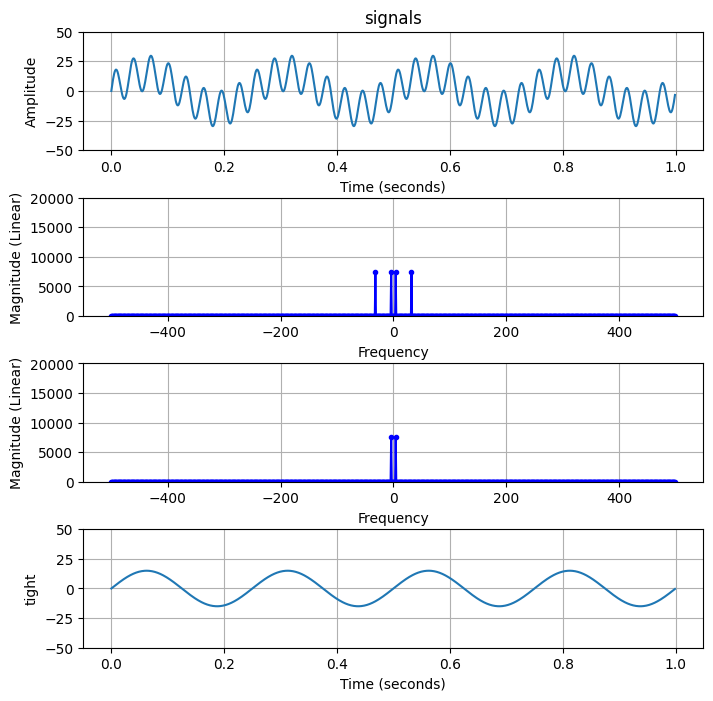

In [ ]:
# 4Hz, 32Hz 2개 각각 크기 15, 15인 신호의 합으로 신호를 만든다.
for i in range(0, N) :
 y[i] = 15*np.sin(2*3.141592*4*i/N)+15*np.sin(2*3.141592*32*i/N)

Y = fft(y) # FFT 변환
print (Y.shape, Y.dtype) # Y는 complex
X = Y
Y = fftshift(Y) # middles the zero-point's axis

for i in range(32, 33) :  # 32Hz 신호를 없앤다
 X[i] = 0.
for i in range(N-32, N-31) :  # 반대편 32Hz 신호도 없앤다
 X[i] = 0.

x = ifft(X, None, -1, None) # 없애고 남은 주파수 부분을 역퓨리에 변환
X = fftshift(X)

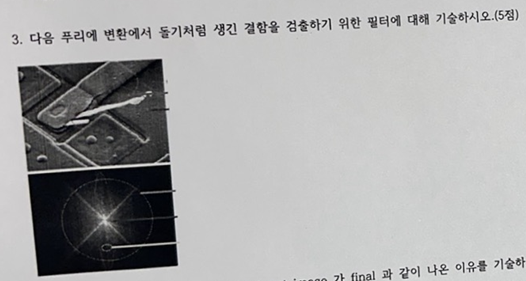

In [ ]:
'''
돌기처럼 생긴 결함을 검출하기 위해서는 결함의 주파수 성문을 강조하거나 제거하는 필터링 기법을 사용해야 합니다.
위 경우에서는 수직 성분을 강조하는 필터와 고주파 필터를 사용하여 결함을 검출하게 됩니다.
'''

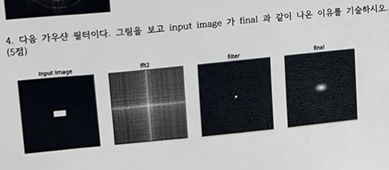

In [ ]:
'''
1. Input Image
  - 원본 이미지는 검은 배경위에 흰색 사각형 한개가 놓여있는 단순한 이미지

2. ff2(주파수 변환된 이미지)
  - 푸리에 변환을 적용한 이미지로 적용 후에는 이미지가 주파수 도메인으로 변환이 된다.
  - 변환된 주파수는 원본 이미지에서 나오는 주파수 성분을 스펙트럼으로 나타내고, 고주파/저주파 성분을 나타낸다

3. Filter
  - 가우샨 필터 이미지로 저주파 필터이다.
  - 중심 주파수 성분에 대해 높은 값을 갖며 그외 고주파 성분은 낮은 값을 갖도록 한다.
  - 원본 이미지를 부드럽게 만드는 역할을 한다.
  - 필터 이미지에서 작은 원 모양이 가우샨 필터를 나타낸다
  - 주파수 도메인에서 저주파는 통과, 고주파는 차단 하게된다.

4. Final
  - 가우샨 필터가 주파수 도메인에서 필터링된 결과로 원본 이미지에서 고주파 성분을 제거하고
    부드럽게 이미지가 변환 되었다.


Input image는 검은 배경위에 흰색 사각형이 놓여진 이미지이고 Final은 해당 이미지에서 경계부분이 부드러워지고
변화가 약해진 이미지이다. Input image가 Final과 같이 나오게된 이유는 고주파 영역을 차단하고
저주파 영역을 통과하는 가우샨 필터를 통과 하였기 때문이다. 고주파에 해당하는 모서리, 꼭짓점 등의 경계가
희미해졌기 때문에 가우샨 필터를 통과하였다고 볼 수 있다.
'''

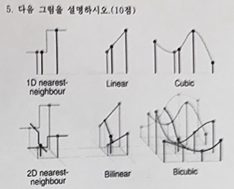

In [ ]:
'''
 ● 1D Nearest-Neighbor (1차원 최근접 이웃 보간법)
  - 1D에서 주어진 값에 가장 가까운 값을 선택하는 방식이다.
  - 간단하지만, 부드럽지 않아 Step(계단형) 모양의 이미지 왜곡이 생길 수 있고 값이 불연속적으로 변화한다.
  - 그래프를 보면 x축을 따라 두 점을 연결했을 때, 값이 갑자기 변화하는 형태를 보인다.
  - 빠르지만, 고급스러운 결과를 원하지 않거나 계산을 빠르게 처리해야 할 때 사용한다.

 ● Linear (선형 보간법)
  - 두 점 사이의 값을 직선으로 연결하여 보간한다. 두 점사이의 값을 linear(선형)으로 추정하는 방식
  - 비교적 부드럽고 예측 가능한 보간법으로 1D에서는 두 점사이를 직선으로 연결하고, 2D에서는 직선 평면을 이용한다.
  - 그래프를 보면 두 점을 직선으로 연결하는 방식을 보이고, 선형적인 변화가 있다.
  - 간단하지만, 보간이 부드러워 이미지를 비교적 잘 처리한다.

 ● Cubic (삼차 보간법)
  - 3차 다항식을 이용하여 두 점 사이의 값을 예측하는 방법으로, 4개의 점을 기준으로 한다.
  - Linear(선형 보간법)보다 훨씬 더 부드럽고 자연스러운 결과를 얻을 수 있다. 특히 곡선 형태의 변화를 잘 처리한다.
  - 그래프를 보면3차 다항식의 형태로 점들이 부드럽게 연결된다. 곡선 형태가 되어, 더 자연스러운 변화를 나타낸다.
  - 부드러운 결과를 원할 때 사용되고, 고품질 이미지를 처리할 때 유용하다.

 ● 2D Nearest-Neighbor (2차원 최근접 이웃 보간법)
  - 2D 이미지에서 각 픽셀에 대해 가장 가까운 이웃 픽셀을 선택하여 값을 할당하는 방법
  - 계산이 빠르지만 1D에서와 마찬가지로 부드럽지 않고 Step(계단)모양이 나올 수 있다.
  - 그래프를 보면 2D 평면에서 각 점을 연결하여 값이 급격하게 바뀌는 모습을 보인다.
  - 빠른 속도가 중요한 경우에 사용된다.

 ● Bilinear (이중 선형 보간법)
  - 2D 선형 보간법으로, 인접한 4개의 점을 기준으로 선형적으로 보간한다.
    수평과 수직 두 축을 기준으로 각각 선형 보간을 진행한다.
  - 부드럽고 자연스러운 결과를 얻을 수 있지만, 고급 보간법 보다는 부드럽지 않을 수 있다.
  - 그래프를 보면 2D의 4개의 점을 직선으로 연결하여, 더 부드럽게 값을 추정한다.
  - 비교적 부드럽고 빠른 게산을 원할 때 사용한다.

 ● Bicubic (이중 삼차 보간법)
  - 2D 삼차 보간법으로, 16개의 점을 기준으로 값을 에측한다.
    더 높은 차원의 다항식을 사용하여 2D에서 보간을 진행한다.
  - 매우 부드럽고 자연스러운 변화를 나타낸다
    이미지에서 고해상도의 디테일을 잘 살린다.
  - 16개의 점을 고려한 삼차 다항식을 사용하여 곡선 형태로 값을 추정한다.
  - 고해상도 이미지나 부드러운 변화를 원하는 경우 사용된다.




※ Nearest-Neighbor: 빠르고 간단하지만 부드럽지 않은 이미지 결과 / 빠른 처리 속도가 중요한 경우

   Linear: 두 점 사이의 선형 보간, 부드러운 결과 / 간단한 처리에서 사용

   Cubic: 3차 다항식을 사용하여 부드럽고 자연스러운 보간 / 이미지 품질을 중요하게 여길 때

   Bilinear: 2D에서 4개의 점을 기준으로 보간, 부드러운 결과 / 빠르면서도 부드러운 결과를 원하는 경우

   Bicubic: 2D에서 16개의 점을 기준으로 보간, 가장 부드럽고 자연스러운 결과 / 고품질, 세밀한 디테일이 중요한 경우
'''

5. 다음 그림에서 L0을 스무딩하는 것과 L2를 스무딩 하는 것이 결과에 미치는 영향을 기술하시오. (5점)

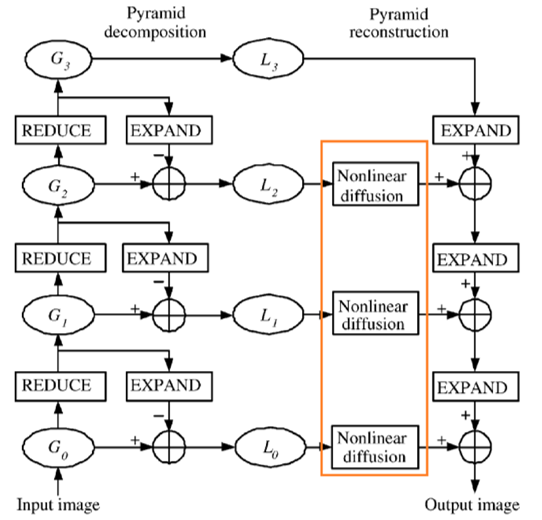

In [ ]:
'''
위 그림은 이미지 피라미드와 비선형 확산에 대해서 묻는 문제이다.

- Pyramid Decomposition(피라미드 분해): 이미지를 점차적으로 낮은 해상도로 축소해 나가는 과정으로 Gn을 만들어 낸다.
                                       REDUCE에서 이미지를 축소하고, EXPAND에서 이미지를 확장한다.

- Nonlinear Diffusion (비선형 확산): 각 레벨에서 Nonlinear Diffusion을 적용하여 이미지를 부드럽게 처리하고,
                              잡음을 제거하는 과정이다. 여기서 이미지를 더욱 부드럽고, 경계가 더 자연스러워진다.

- Pyramid Reconstruction (피라미드 재구성): 각 레벨에서 축소된 이미지를 다시 복원하는 과정.
                                          EXPAND 단계를 통해 고해상도 이미지를 복원하고, 최종적으로 더 나은 품질의
                                          이미지를 얻게 된다.

 ● L0와 L2 스무딩
  - L0와 L2를 각각 스무딩 처리하면 잡음 제거와 세부 사항 부드럽게 처리가 이루어진다.
  - L0은 원본 이미지에서 가장 높은 해상도를 갖는 이미지이다. 이 이미지를 Nonlinear Diffusion을 통해 부드럽게 하면
    잡음이 줄어들고 이미지의 세부사항이 자연스럽게 표현된다.
  - L2는 더 낮은 해상도의 이미지를 나타내며, 이 이미지를 스무딩하면 더 넓은 영역에서 부드러운 변화를 얻을 수 있다.

L0와 L2를 각각 스무딩 하게되면, 이미지에서 잡음 제거와 세부사항 강조가 이루어진다. 각 레벨에서 이미지의 경계가
부드럽게 처리되며, 최종적으로 더 깨끗한 이미자 완성된다.

L0과 L2에서 Nonlinear Diffusion을 적용하면, 이미지에서 잡음이 줄어들고 세부사항이 강조된다.
Pyramid Decomposition을 통해 이미지를 점차 축소하고, Pyramid Reconstruction을 통해 고해상도 이미지를 복원한다.
Nonlinear Diffusion은 이미지를 부드럽게 만들어 잡음을 줄이고, 경계를 자연스럽게 처리한다.
'''

6. 다음 프로그램을 설명하시오. (5점)

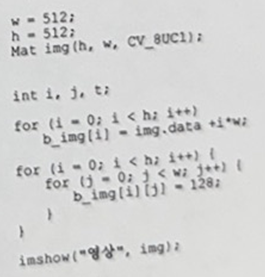

In [ ]:
'''
위 코드는 512X512 크기의 이미지를 생성하고 그 이미지를 128(회색) 값으로 채운 후
imshow를 이용하여 화면에 표시하는 코드이다.

 ● w = 512;
    h = 512;                  -> w와 h를 이용하여 너비와 높이를 정의하고 값을 512로 줌
    Mat img(h, w, CV_8UC1);   -> 정의한 w, h를 사용하여서 8비트 그레이스케일 이미지를 생성

 ● for (i = 0; i < h; i++) {
       b_img(i) = img.data + i * w;  -> b_img(i): i번째 행을 나타내는 포인터
    }                                   b_img(i)에 w를 곱하여서 i번째 행의 첫 번째 픽셀을 계산하게 된다.

    ※img.data: 이미지의 픽셀 값이 시작되는 메모리 주소( 배열의 첫 번째 요소 )
      Mat: 내부적으로 data 배열을 사용하여 이미지를 저장한다.

 ● for (i = 0; i < h; i++) {
       for (j = 0; j < w; j++) {
            b_img(i)(j) = 128;      -> i와 j값에 따른 픽셀의 값을 128(회색)로 지정한다
       }
    }

    ※ i는 행, j는 열을 나타내며 이중 for문을 통하여서 이미지의 모든 픽셀을 하나씩 처리하게 된다.

'''

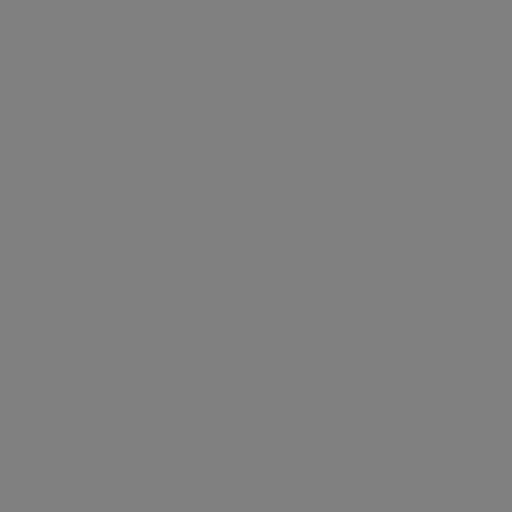

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

# 이미지 크기 설정
h = 512
w = 512

# 이미지 생성 (흑백 이미지, 8-bit, 단일 채널)
img = np.zeros((h, w), dtype=np.uint8)

# 행별로 값 설정
for i in range(h):
    for j in range(w):
        img[i, j] = 128  # 모든 픽셀을 128로 설정

# 이미지 출력
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()
